In [1]:
import keras
from keras import layers, Sequential
import keras_hub

2026-06-14 08:30:42.980383: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781425843.188280      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781425843.247263      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781425843.746396      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781425843.746437      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781425843.746440      58 computation_placer.cc:177] computation placer alr

In [2]:
model = keras_hub.models.ImageClassifier.from_preset('resnet_50_imagenet')

I0000 00:00:1781425861.987895      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1781425861.993899      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [3]:
# downloading the image from a given link
img_path = keras.utils.get_file('cockroach.jpg',origin="https://t3.ftcdn.net/jpg/11/76/76/16/240_F_1176761666_olVGARI8N0HPXDE42jJ2tI5rI1hc8fqK.jpg")

# loading the img from the directory
img = keras.utils.load_img(img_path)

21189/21189 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


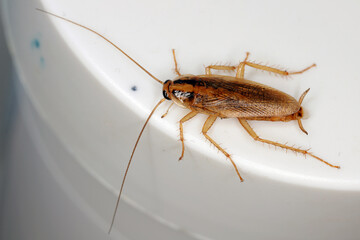

In [4]:
img

In [5]:
import numpy as np

In [6]:
x = keras.utils.img_to_array(img)
x = np.expand_dims(x, axis=0)
x

array([[[[120., 125., 128.],
         [124., 129., 132.],
         [127., 135., 137.],
         ...,
         [221., 222., 216.],
         [221., 222., 216.],
         [221., 222., 216.]],

        [[119., 124., 127.],
         [124., 129., 132.],
         [127., 135., 137.],
         ...,
         [221., 222., 217.],
         [221., 222., 216.],
         [221., 222., 216.]],

        [[119., 124., 127.],
         [123., 128., 131.],
         [126., 134., 136.],
         ...,
         [221., 222., 217.],
         [221., 222., 217.],
         [221., 222., 216.]],

        ...,

        [[ 81.,  82.,  84.],
         [ 82.,  83.,  85.],
         [ 84.,  85.,  87.],
         ...,
         [152., 147., 141.],
         [152., 147., 141.],
         [152., 147., 141.]],

        [[ 81.,  82.,  84.],
         [ 82.,  83.,  85.],
         [ 84.,  85.,  87.],
         ...,
         [150., 145., 139.],
         [150., 145., 139.],
         [150., 145., 139.]],

        [[ 81.,  82.,  84.],
       

In [7]:
prediction = model.predict(x)

I0000 00:00:1781425869.528402     131 service.cc:152] XLA service 0x7a93740041a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1781425869.528435     131 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1781425869.528439     131 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1781425870.240745     131 cuda_dnn.cc:529] Loaded cuDNN version 91002


1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


I0000 00:00:1781425873.399806     131 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


In [8]:
prediction

array([[-11.306295 ,  -9.775593 ,  -9.449427 , -10.832885 ,  -9.371392 ,
         -9.427868 , -10.332375 , -10.442068 , -10.440242 , -10.533808 ,
        -11.434183 , -10.614653 , -10.032467 , -10.872752 , -10.784833 ,
        -12.254454 , -10.746352 , -10.321358 ,  -9.205353 , -11.389072 ,
        -11.456304 , -11.019165 , -11.961721 , -11.059589 , -11.261818 ,
        -11.519527 , -10.592526 , -10.844358 , -11.775228 ,  -9.268982 ,
        -11.630475 , -11.437628 , -11.342675 , -10.261534 ,  -9.3582115,
        -10.899815 , -10.443172 ,  -9.085854 , -11.339638 , -12.175005 ,
         -9.190285 , -13.154047 , -11.383363 , -10.523278 ,  -9.795404 ,
        -12.800978 , -10.707281 , -10.691305 , -11.529043 , -11.477905 ,
         -9.99383  , -10.281498 , -12.446744 , -10.355698 , -11.53401  ,
        -11.689272 , -12.967157 , -12.878609 , -12.757924 , -10.535414 ,
        -11.306735 , -12.072128 , -11.705694 , -10.502138 , -11.430184 ,
        -11.276271 , -11.525379 , -11.114652 , -12.

In [9]:
decoded_prediction = keras_hub.utils.decode_imagenet_predictions(prediction)

In [10]:
decoded_prediction[0][0]

('cockroach', 9.598340034484863)

### **Making a function to do the same thing**

Just put the link in the function and it will do the prediction

In [11]:
import hashlib

In [12]:
def make_prediction(img_link):
    name = hashlib.md5(img_link.encode("utf-8")).hexdigest() + ".jpg"          # creates unique names for all the links which are being sent to the function
    img_path = keras.utils.get_file(name, origin=img_link)                     # storing the img in directory

    img = keras.utils.load_img(img_path)                                       # loading the img form the directory
    x = keras.utils.img_to_array(img)
    x = np.expand_dims(x, axis=0)

    prediction = model.predict(x)           # gives an array
    final_prediction = keras_hub.utils.decode_imagenet_predictions(prediction)

    return final_prediction[0][0]
    

In [13]:
make_prediction("https://t3.ftcdn.net/jpg/11/76/76/16/240_F_1176761666_olVGARI8N0HPXDE42jJ2tI5rI1hc8fqK.jpg")

21189/21189 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step


('cockroach', 9.598340034484863)

**Observation :** The numbers showing besides the prediction, represents the confidense in the answer. The higher the better,

In [14]:
make_prediction("https://imgs.search.brave.com/4JtVJb65xVYb6_-nvf7NNkNhqWQsDmTKbbEjs28Nms4/rs:fit:500:0:1:0/g:ce/aHR0cHM6Ly9pbWFn/ZXMudW5zcGxhc2gu/Y29tL3Bob3RvLTE1/MTc2NDkyODEyMDMt/ZGFkODM2YjRhYmU1/P2ZtPWpwZyZxPTYw/Jnc9MzAwMCZhdXRv/PWZvcm1hdCZmaXQ9/Y3JvcCZpeGxpYj1y/Yi00LjEuMCZpeGlk/PU0zd3hNakEzZkRC/OE1IeGxlSEJzYjNK/bExXWmxaV1I4TVRO/OGZIeGxibnd3Zkh4/OGZIdz0")

20512/20512 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step


('lion', 6.38811731338501)

In [15]:
# img of human eye
print(make_prediction("https://imgs.search.brave.com/W48xbsJ4kDy2HOmTI3WUDC-9AH_Z6ki_k2O1FwVK5Oo/rs:fit:500:0:1:0/g:ce/aHR0cHM6Ly93d3cu/cGJzLm9yZy93Z2Jo/L25vdmEvbWVkaWEv/aW1hZ2VzL0VwaXNv/ZGljLTAxX0NsZWFu/X0RpZ2l0YWxfMTZY/OS53aWR0aC0yMDAw/LmpwZw"))

14310/14310 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
('coil', -1.9829237461090088)


In [16]:
# img of a human being
print(make_prediction("https://imgs.search.brave.com/CGGqgukmjvEsTT_S3kCUzLKmC_ClEYE7le6OKnbOitg/rs:fit:500:0:1:0/g:ce/aHR0cHM6Ly9tZWRp/YS5pc3RvY2twaG90/by5jb20vaWQvMTAw/OTc0OTYwOC9waG90/by95b3VuZy13b21h/bi1wb3J0cmFpdC1p/bi10aGUtY2l0eS5q/cGc_cz02MTJ4NjEy/Jnc9MCZrPTIwJmM9/bkJtZFhyQ2tJNlp6/LUoxRWtDR1FBYW1h/WWxaZUlPUUF0S3Vu/QzRXTVQtVT0"))

21535/21535 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
('gondola', -2.745933771133423)


In [18]:
# img of robots
print(make_prediction("https://imgs.search.brave.com/8NPJyARBIGIdimSQcENMpO8NobeZ_0CU7exXFpaRzUQ/rs:fit:500:0:1:0/g:ce/aHR0cHM6Ly9tZWRp/YS5pc3RvY2twaG90/by5jb20vaWQvMjIy/MzgxMjg2Ny9waG90/by9wb3J0cmFpdC1v/Zi1vcmFuZ2UtYWkt/ZW5hYmxlZC1odW1h/bm9pZC1pbmR1c3Ry/aWFsLXJvYm90LXdp/dGgtYmxhY2stdmlz/b3ItYXV0b25vbW91/cy1odW1hbm9pZC53/ZWJwP2E9MSZiPTEm/cz02MTJ4NjEyJnc9/MCZrPTIwJmM9azlS/TE5Ld0lyNlZQY3pB/aW9RakRJZFp6M24x/WTMwS3NSS1NZbFo2/R1Jwcz0"))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
('lifeboat', 1.0914678573608398)


---

In [33]:
# 2D array : 2 row 5 cols
a= np.array([[1,2,3,4,5],
             [6,7,8,9,10],
             [11,22,33,44,55]])

In [39]:
print(a[0])
print(a[0][0])
print(a[0][1])
print(a[1])
print(a[1][0])
print(a[2])
print()
print(a)

[1 2 3 4 5]
1
2
[ 6  7  8  9 10]
6
[11 22 33 44 55]

[[ 1  2  3  4  5]
 [ 6  7  8  9 10]
 [11 22 33 44 55]]


In [49]:
# 3D array : shape is (2,2,5)

b = np.array([[[1,2,3,4,5],
               [6,7,8,9,10]],
              
              [[11,22,33,44,55],
               [66,77,88,99,111]]])

print(b)
print()
print(b[1])
print()
print(b[0])
print()
print(b[0][0])
print()
print(b[0][0][0])


[[[  1   2   3   4   5]
  [  6   7   8   9  10]]

 [[ 11  22  33  44  55]
  [ 66  77  88  99 111]]]

[[ 11  22  33  44  55]
 [ 66  77  88  99 111]]

[[ 1  2  3  4  5]
 [ 6  7  8  9 10]]

[1 2 3 4 5]

1
